# FASE 4: INTERPRETABILIDAD Y EXPLICABILIDAD DEL MODELO

## 1. Marco Teórico: Interpretabilidad vs. Explicabilidad

En esta fase final, el objetivo es transformar los resultados matemáticos en conocimiento accionable para la toma de decisiones estratégicas. Para ello, es fundamental distinguir entre los dos conceptos que rigen la transparencia de nuestra IA:

### **A. Interpretabilidad (Modelos de "Caja Blanca")**
La interpretabilidad se refiere a la capacidad de un modelo para ser comprendido por un humano gracias a su propia estructura interna, sin necesidad de herramientas adicionales.
* **Aplicación en el proyecto:** Nuestra **Regresión Logística (Fase 2)** es un modelo intrínsecamente interpretable. Al observar sus coeficientes, podemos entender directamente la dirección y magnitud del efecto de variables como la jornada laboral o el sueldo sobre la probabilidad de rotación.

### **B. Explicabilidad (Modelos de "Caja Negra")**
La explicabilidad se aplica a modelos complejos (como el **Random Forest** o **Gradient Boosting** de la Fase 3) que, debido a su arquitectura de cientos de árboles, no son legibles de forma directa. Para "explicarlos", utilizamos técnicas *post-hoc* que nos ayudan a justificar por qué el modelo toma ciertas decisiones.
* **Aplicación en el proyecto:** Al no poder leer los 200 árboles de nuestro Random Forest optimizado, recurriremos al análisis de **Feature Importance** (Importancia de las Variables) para identificar qué factores están "moviendo la aguja" en el comportamiento de los egresados.

> **Conclusión:** Mientras que la **Interpretabilidad** nos dio la base científica y el sentido de la relación entre variables, la **Explicabilidad** nos permite validar la potencia del modelo avanzado y confiar en sus predicciones para el diseño de políticas de retención.

In [3]:
%pip install shap 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 4.7 MB/s eta 0:00:0000:0100:01
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 6.2 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 7.3 MB/s eta 0:00:0000:0100:01m
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Carga de datos
df_encoded = pd.read_csv('../data/EILU_MAST_2019_limpio.csv')

# 2. Definición de variables (idéntico a los notebooks anteriores)
vars_nominales = ['RAMA', 'T_UNIV', 'SEXO', 'PR_JOR', 'SAT2', 'TIC', 'MVFUERA']
vars_num_ord = ['PR_SUELDO', 'IDIOMAS', 'N_CURS', 'EDAD']

# 3. Preprocesador y Modelo (El que ganó en la Fase 3)
preprocesador = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), vars_nominales),
    ('num', StandardScaler(), vars_num_ord)
])

best_rf_model = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42))
])

# 4. Split y Entrenamiento rápido
X = df_encoded.drop('P_CONTI', axis=1)
y = df_encoded['P_CONTI']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
best_rf_model.fit(X_train, y_train)

print("✅ Entorno listo y modelo recuperado.")

✅ Entorno listo y modelo recuperado.


Gráfico de Resumen SHAP (Impacto en la Predicción):


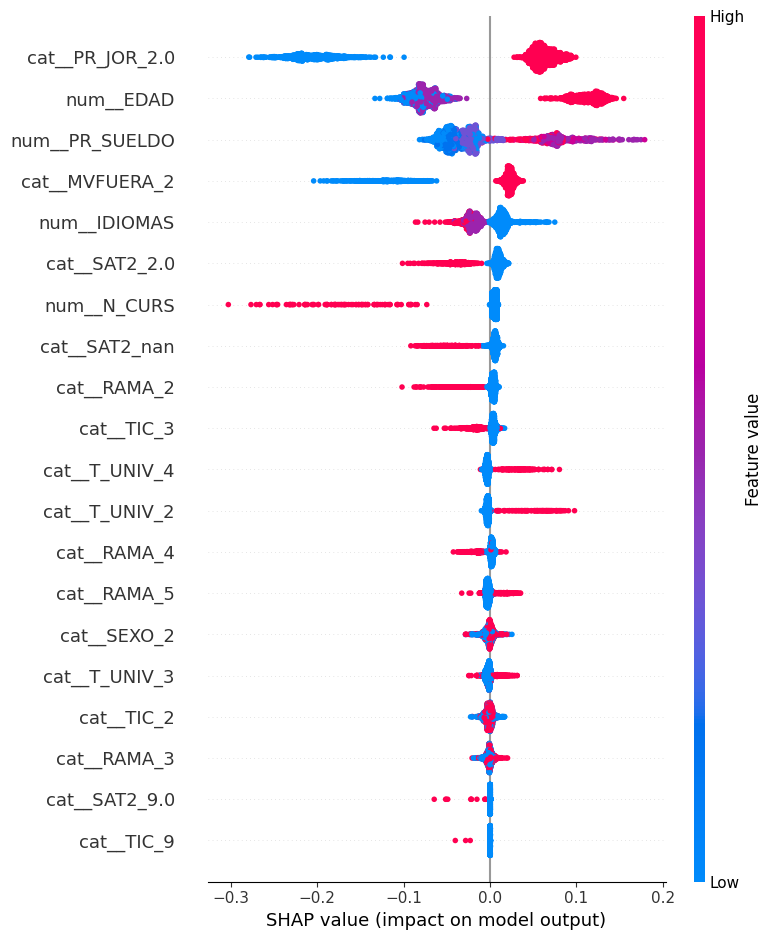

In [6]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparación: Convertimos los datos a un formato denso y legible
X_test_transformed = preprocessor.transform(X_test)

# Si el preprocesador devuelve una matriz dispersa (sparse), la pasamos a densa
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = list(preprocessor.get_feature_names_out())
X_test_disp = pd.DataFrame(X_test_transformed, columns=feature_names)

# 2. Creamos el explicador SHAP (Agnóstico al modelo)
# Los métodos agnósticos permiten mantener la independencia del modelo.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_disp)

# 3. Solución al AssertionError: Manejo de dimensiones para clasificación binaria
# En Random Forest, SHAP suele devolver una lista [valores_clase_0, valores_clase_1]
if isinstance(shap_values, list):
    # Seleccionamos la clase 1 (Retención / P_CONTI=1) para el análisis
    shap_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Si viene como array 3D (muestras, variables, clases), seleccionamos la última dimensión
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

# 4. Generación del Gráfico de Resumen SHAP (Global)
print("Gráfico de Resumen SHAP (Impacto en la Predicción):")
# Este gráfico muestra la contribución de cada característica según la teoría de juegos.
shap.summary_plot(shap_to_plot, X_test_disp)

Hemos implementado el método **SHAP**, cuyos fundamentos provienen de la teoría de juegos. 
* **Funcionamiento:** El valor de Shapley mide la contribución de cada característica a la predicción del modelo, considerando todas las combinaciones posibles de variables.
* **Alcance:** Aunque SHAP es principalmente local, mediante la agregación de valores obtenemos resultados globales del impacto de cada variable.

## 3. Análisis de Resultados (Interpretación Global)

A partir del gráfico de resumen SHAP (*Summary Plot*), extraemos las relaciones aprendidas por el modelo para identificar los motores de la rotación laboral:

1. **Impacto de la Jornada Laboral (`cat__PR_JOR_2.0`):** Es la variable con mayor peso global. Los valores altos (representados en rosa) muestran un impacto positivo muy fuerte en la salida del modelo, lo que indica que la jornada parcial es el principal detonante de la rotación.
2. **Influencia de la Edad (`num__EDAD`):** Se observa una tendencia clara donde los perfiles de mayor edad (puntos rojos) presentan una correlación directa con el riesgo de abandono del primer empleo.
3. **Variable Salarial (`num__PR_SUELDO`):** Los niveles salariales altos muestran una dispersión significativa hacia la derecha del eje, sugiriendo que la alta cualificación remunerada también está asociada a una mayor movilidad externa.
4. **Perfil Internacional (`cat__MVFUERA_2`):** Haber realizado estancias en el extranjero aumenta consistentemente la probabilidad de rotación, situando a este perfil como uno de los más volátiles en el mercado laboral inicial.

**Conclusión:** Este análisis de explicabilidad nos permite entender no solo qué predice el modelo, sino los mecanismos internos que rigen el mercado laboral de los egresados de máster.